# Detecção de Fraude em Cartões de Crédito

Projeto final do curso de Data Science da EBAC. O objetivo é construir um modelo de machine learning capaz de identificar transações fraudulentas em cartões de crédito a partir de um dataset com mais de 284 mil transações.

O principal desafio deste projeto é o desbalanceamento extremo das classes: apenas 0.17% das transações são fraudes. Isso exige cuidado especial na escolha de métricas, na estratégia de validação e na forma de lidar com a classe minoritária — problemas comuns em aplicações reais de detecção de fraude no mercado financeiro.

# Importações

In [8]:
# Importações para arquivos

from pathlib import Path

# Importações para dados

import pandas as pd
import numpy as np

# Importações para gráficos

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# importações para pré-processamento

from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold, RandomizedSearchCV

# Importações para modelos de ML

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Importações para métricas

from sklearn.metrics import classification_report, confusion_matrix

## Dicionário da Base

| Variável | Definição |
|----------|-----------|
| **V1 — V28** | Componentes obtidos via PCA — variáveis originais anonimizadas por questões de confidencialidade |
| **Time** | Segundos decorridos desde a primeira transação do dataset |
| **Amount** | Valor da transação |
| **Class** | Variável target — 0 = transação legítima, 1 = fraude |

# Carregando Base de Dados

In [5]:
# Deifinindo caminho do arquivo

path = "./DATA_CREDIT_CARD_FRAUD.csv"

# Verificando se o caminho existe

if Path(path).exists():
    print("O arquivo foi encontrado! ")
    df = pd.read_csv(path)

else:
    print("O arquivo não foi encontrado. ")


df

O arquivo foi encontrado! 


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


# Limpeza de dados

- Vefiricando se há valores nulos e se os types estão corretos

In [ ]:
# Uitlizando info para descobrir se há valores nulos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Obs: Não há valores nulos, e mesmo que ouvessem outliers, agora não seria mais possível identificar pois a maioria das colunas passaram por PCA, redução de dimensionalidade, logo, entende-se, que elas já foram tratadas.

# EDA

Como a base de dados já passoui por PCA, não temos muitas opções para explora-la, então vamos fazer apenas 3 gráficos para entender melhor como as varíaveis se relacionam. <br>
O primeiro vai ser um histograma de Time x Class, para descobrir se as fraudes acontecem com mais frequencia em algum momento específico. <br>
O segundo vai ser um boxplot de Amount x Class, para descobrir se as fraudes aprensentam valores muito diferentes das compras legítimas. <br>
Por último, um gráfico para mostrar as correlações com a categoria class

- Time x Class

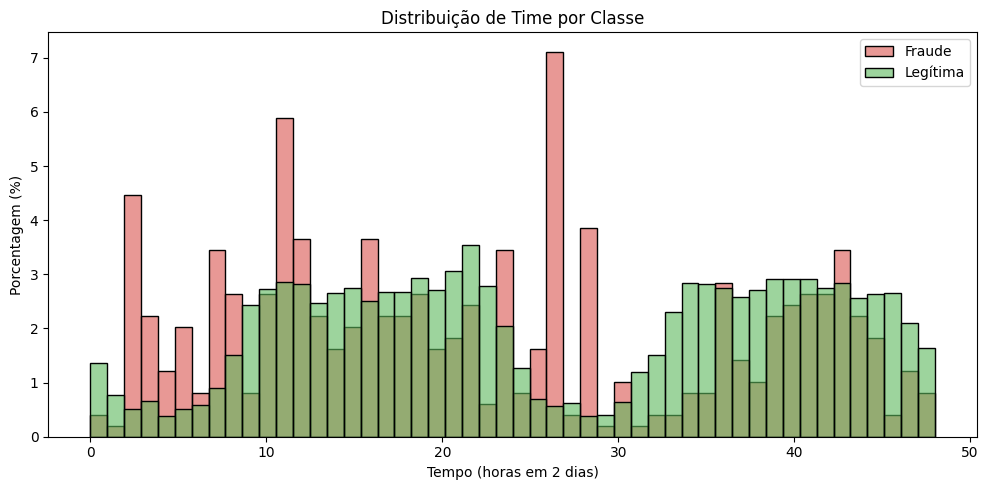

In [24]:
# Criando coluna tempo em horas para facilitar interpretação no gráfico

df['Time_hours'] = df['Time'] / 3600

# Criando histograma da distribuição de Time por classe

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Time_hours', hue='Class', bins=50, alpha=0.6,
             stat='percent', common_norm=False,
             palette={0: '#5cb85c', 1: '#d9534f'})
plt.title('Distribuição de Time por Classe')
plt.xlabel('Tempo (horas em 2 dias)')
plt.ylabel('Porcentagem (%)')
plt.legend(labels=['Fraude', 'Legítima'], title='')
plt.tight_layout()
plt.show()

# Removendo coluna que foi criada apenas para facilitar a visualização do gráfico

df = df.drop(columns='Time_hours')

Obs: O dataset cobre aproximadamente 48 horas de transações (172.792 segundos), mas não há informação sobre o horário real de início da coleta — o que limita qualquer conclusão sobre horários exatos. Ainda assim, o histograma revela um padrão interessante: a distribuição temporal das fraudes tem formato diferente da distribuição das legítimas. Nos períodos em que a atividade geral de transações cai (possivelmente horários de madrugada), a concentração relativa de fraudes aumenta. Isso faz sentido do ponto de vista de negócio — horários de baixa atividade significam menos monitoramento ativo e mais tempo até a vítima perceber a cobrança indevida. O padrão não é de proporção inversa exata, mas sugere que a variável Time pode carregar informação útil para o modelo, especialmente se combinada com outras features.

- Amount x Class

In [ ]:
# Criando boxplot da distribuição de Amount por classe

fig = px.box(df, x='Class', y='Amount', color='Class',
             color_discrete_map={0: '#5cb85c', 1: '#d9534f'},
             title='Distribuição de Amount por Classe (escala log)',
             labels={'Amount': 'Valor da Transação', 'Class': 'Classe'})
fig.update_yaxes(type='log')
fig.show()

Obs: O boxplot em escala logarítmica revela que as medianas das duas classes são relativamente próximas — R$22 para transações legítimas e R$9.25 para fraudes — mas a diferença no teto máximo é expressiva: transações legítimas chegam a R$25.691, enquanto o maior valor fraudulento registrado é de R$2.125, quase 12 vezes menor. Isso sugere que fraudes de valores muito altos são raras ou inviáveis, possivelmente porque sistemas bancários exigem confirmações adicionais para transações acima de certos limites, funcionando como uma barreira natural, ou seja o teto máximo para fraudes é muito menor que o teto máximo para transações legítimas. Por outro lado, a proximidade das medianas mostra que não é correto afirmar que "fraude é sempre valor baixo" — o padrão é mais sutil do que isso. A variável Amount carrega informação útil para o modelo, mas não é um separador direto entre as classes.

- Correlações com Class

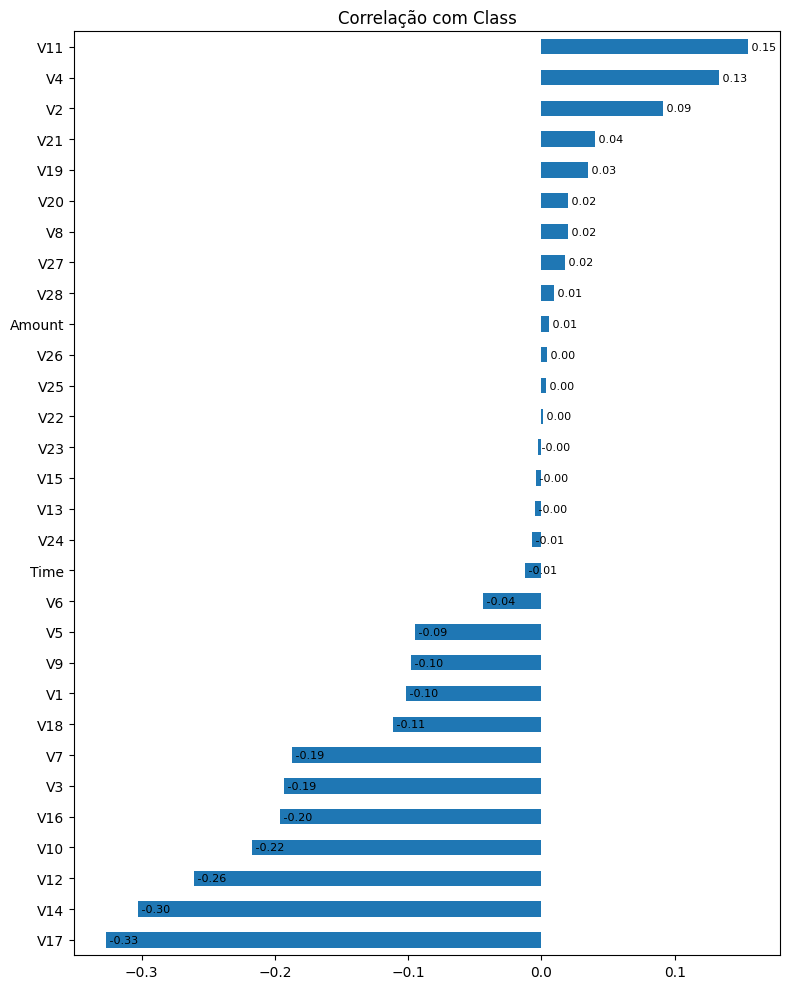

In [30]:
# Correlações com a categoria Class

corr_class = df.corr()['Class'].drop('Class').sort_values()

# Criando gráfico

ax = corr_class.plot(kind='barh', figsize=(8, 10), title='Correlação com Class')
for i, v in enumerate(corr_class):
    ax.text(v, i, f' {v:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

Obs: A matriz de correlação com 31 variáveis ficou visualmente difícil de interpretar, então um gráfico de barras com a correlação de cada feature com Class ajudou a identificar os padrões. Como as V1-V28 vêm de PCA e são anônimas, não é possível interpretar o significado de cada correlação — mas o modelo consegue explorar esses padrões mesmo sem a gente saber o que cada componente representa. As correlações negativas mais fortes com Class são V17 (-0.33), V14 (-0.30), V12 (-0.26) e V10 (-0.22), enquanto do lado positivo V11 (0.15) e V4 (0.13) se destacam. Já Time e Amount, as duas variáveis que conhecemos, apresentaram correlações praticamente nulas com Class (0.01 nos dois casos), indicando que isoladamente nenhuma das duas é um preditor forte de fraude — embora os padrões observados na EDA anterior (concentração temporal e teto de valor) possam ser capturados pelo modelo em combinação com outras features.

# Pré-processamento

- Padronização

Como os dados já estão padronizados e usaremos modelos de árvores, não será necessário se preocupar com padronização. 

- Balanceamento

In [ ]:
# Verificando o balanceamento

print(df['Class'].value_counts())

# Verificando o balanceamento em porcentagens

print(df['Class'].value_counts(normalize=True))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


Os dados estão extremamente desbalanceados, cerca de apenas 0,17 por cento dos dados são fraudes, o que tornaria extremamente ideal balancear, mas não o faremos inicialmente, pois pela alta quantidade de dados, qualquer balanceamento geraria uma quantidade absurda de valores fictícios ou retiraria muitos valores, e fraudes possuem padrões extremamente sútis, logo inicialmente faremos o teste concentrando nos hiperparâmetros pala lidar com o desbalanceamento.